<a href="https://colab.research.google.com/github/aparna-2001/basic_BCI_analysis/blob/main/S001R12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install mne

In [16]:
import mne
from mne.decoding import CSP
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

Extracting EDF parameters from S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


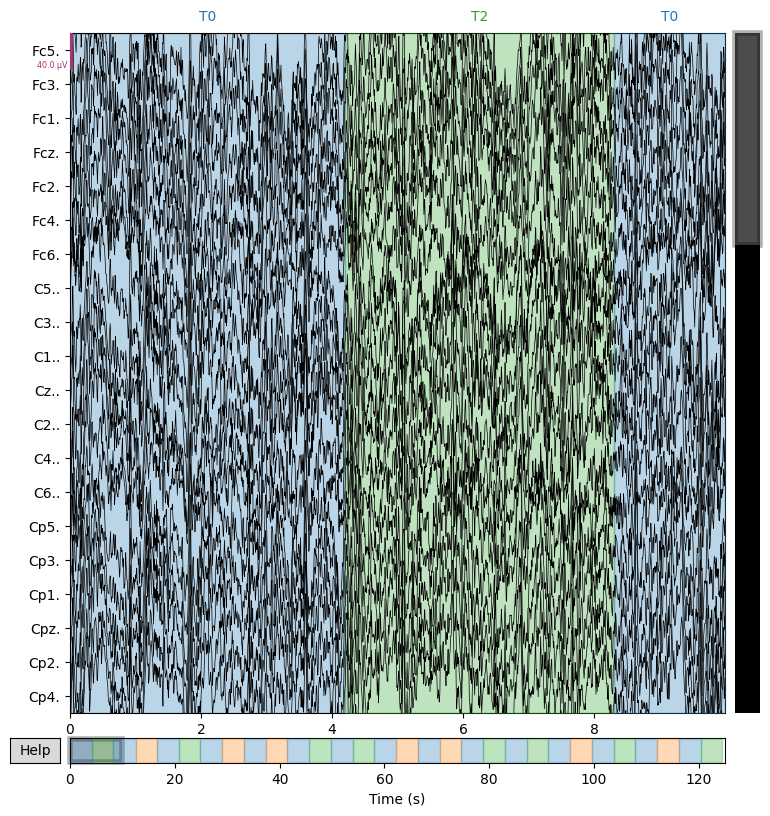

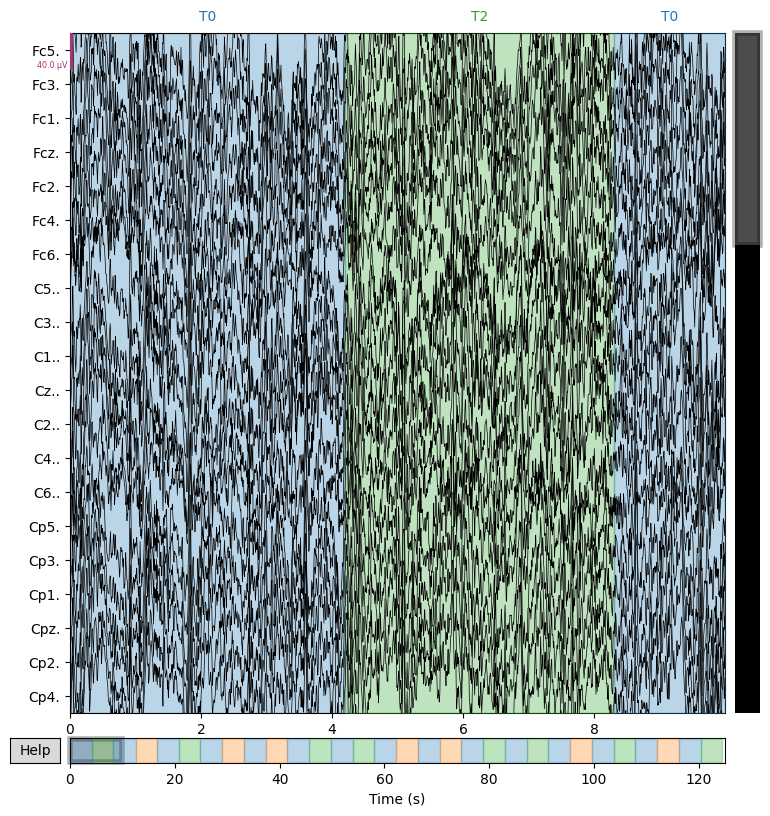

In [17]:
#loading the data
raw = mne.io.read_raw_edf('S001R12.edf', preload = True)
raw.plot()

In [18]:
#filtering the required band

raw.filter(8, 30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R12.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [19]:
#event extraction

events, event_id = mne.events_from_annotations(raw)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


In [20]:
#epoch extraction
epochs = mne.Epochs(raw = raw,
           events = events,
           event_id = event_id,
           tmin = 0,
           tmax = 4,
           baseline = None,
           preload = True)

epoch_T0 = epochs['T0']
epoch_T2 = epochs['T2']

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


In [21]:
#labels


In [22]:
#data from the epoch
data_T0 = epoch_T0.get_data()
data_T2 = epoch_T2.get_data()

In [25]:
#concatenating
x = np.concatenate([data_T0, data_T2])
y = np.concatenate([np.zeros(len(epoch_T0)), np.ones(len(epoch_T2))])

In [26]:
#csp
csp = CSP(n_components= 4, log = True)
x_csp = csp.fit_transform(x,y)
print(x_csp.shape)

Computing rank from data with rank=None
    Using tolerance 0.00021 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.
(23, 4)


In [27]:
#LDA

clf = LinearDiscriminantAnalysis()
clf.fit(x_csp, y)

LinearDiscriminantAnalysis()

In [30]:
#training and test data
x_train, x_test, y_train, y_test = train_test_split(x_csp, y, test_size= 0.3, random_state= 45)



#fitting
clf.fit(x_train, y_train)

#scoring
score = clf.score(x_test, y_test)
print(score)


#prediction
y_pred = clf.predict(x_test)
print(y_pred)

1.0
[0. 1. 1. 0. 1. 0. 0.]


In [31]:
#validation using confusion matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4 0]
 [0 3]]
